In [2]:
# Tratamiento de datos
import pandas as pd
import numpy as np

#Graficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Procesado y modelado
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels as sms


# configuración de matplotlib
plt.rcParams['image.cmap']="bwr"
plt.rcParams['figure.dpi']="100"
plt.rcParams['savefig.bbox']="tight"
style.use('ggplot') or plt.style.use('ggplot')

# configuración de warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Lectura de datos

In [20]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera

In [4]:
data = pd.read_csv('Advertising.csv')

# Análisis Exploratorio descriptivo

```
# Tiene formato de código
```



In [5]:
data.isna().sum() #Contamos los datos N/A y los sumamos

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [6]:
data.describe() #Hacemos un resumen de indicadores descriptivos std es desviación estándar



,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
data.columns #Visualizamos las columnas de nuestra DB

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [ ]:
#data = data.drop("Unnamed: 0", axis=1)

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

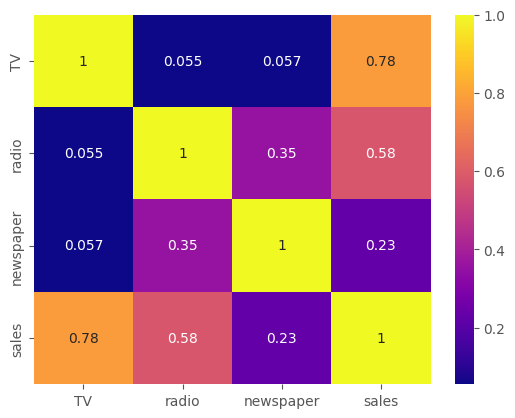

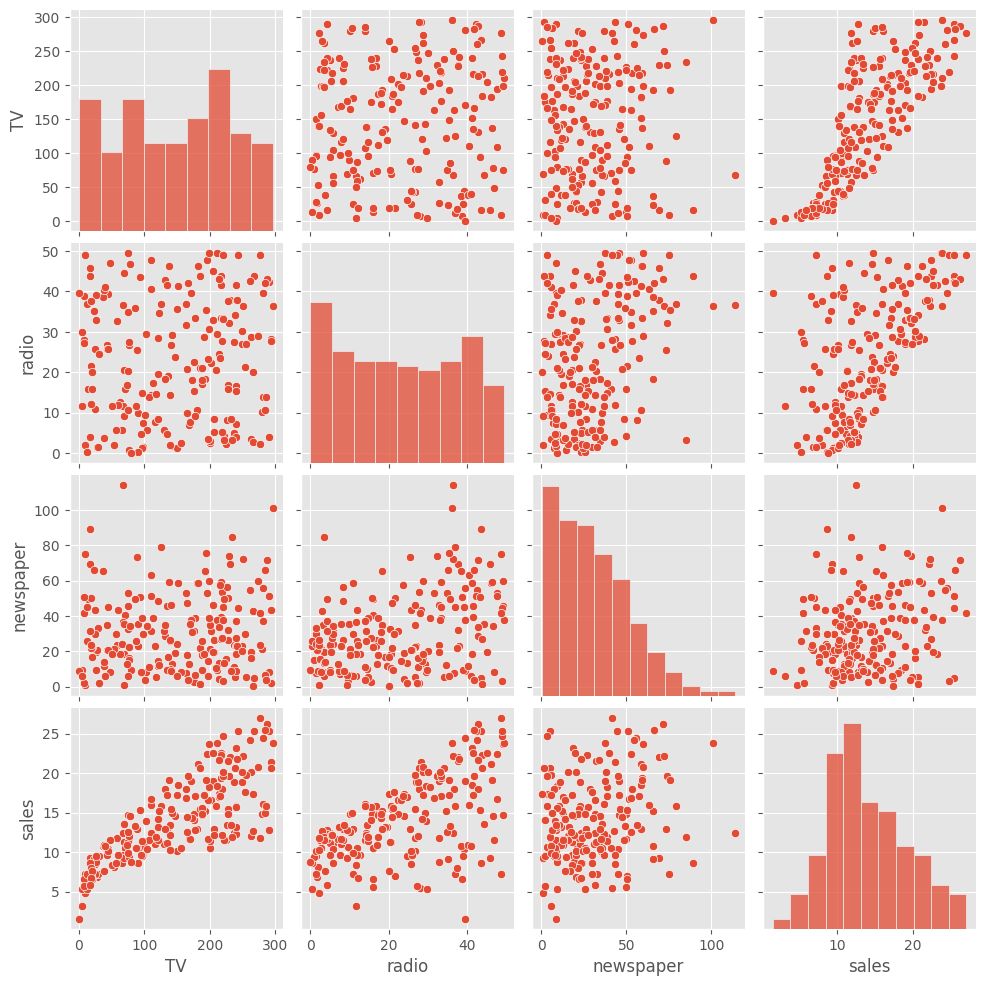

# Ajsute del modelo múltiple

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [12]:
#X_orig = pd.DataFrame(data=data, columns=['TV','radio'])
#X_orig.head()
X_orig = pd.DataFrame(data=data, columns=['TV','radio','newspaper'])
X_orig.head()


,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [13]:

y_orig = data['sales']
y_orig.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64

In [ ]:
#X = pd.DataFrame(data.drop('sales',axis=1))
#X.head()

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_orig, y_orig, random_state=123,train_size = 0.8) #75% para entrenamiento, 25% para prueba
df = pd.concat([X_train,y_train], axis=1)
X_train.shape
X_test.shape
y_train.shape
y_test.shape


(40,)

In [15]:
X_train=sm.add_constant(X_train, prepend=True)
modelo=sm.OLS(y_train, X_train)
modelo=modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     409.8
Date:                Sat, 01 Mar 2025   Prob (F-statistic):           9.89e-74
Time:                        10:14:36   Log-Likelihood:                -313.24
No. Observations:                 160   AIC:                             634.5
Df Residuals:                     156   BIC:                             646.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9242      0.365      8.018      0.0

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     409.8
Date:                Tue, 11 Feb 2025   Prob (F-statistic):           9.89e-74
Time:                        19:38:51   Log-Likelihood:                -313.24
No. Observations:                 160   AIC:                             634.5
Df Residuals:                     156   BIC:                             646.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9242      0.365      8.018      0.0

## Supuestos del modelo

In [18]:
#Normalidad de los errores

resid_val=modelo.resid
fitted_val=modelo.predict()
print(f"Media de los residuales: {modelo.resid.mean()}")
print(f"Desviación estándar de los residuales: {modelo.resid.std()}")

Media de los residuales: 9.026113190202522e-15
Desviación estándar de los residuales: 1.719331353813533


In [21]:
stat, p_value, _, _ = jarque_bera(resid_val)
 
print(f'Estadístico de Jarque-Bera: {stat:.4f}')
print(f'P-valor: {p_value:.4f}')
 
if p_value > 0.05:
    print("No se rechaza H0: Los residuos parecen normales")
else:
    print("Se rechaza H0: Los residuos NO son normales")

Estadístico de Jarque-Bera: 123.5120
P-valor: 0.0000
Se rechaza H0: Los residuos NO son normales


Text(0.5, 1.0, 'Fitted vs Observed')

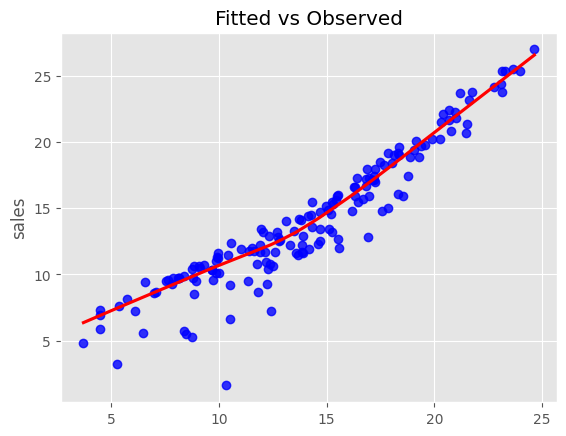

In [22]:
#LINEALIDAD DEL MODELO
sns.regplot(x=fitted_val,y = y_train, color='blue', lowess=True, line_kws={'color':'red'})
plt.title('Fitted vs Observed')

In [ ]:
#CORRELACION DE DURBIN-WATSON
#Hipotesis H_0 No hay autocorrelacion elos residuos rho=0
#H_1 Existe autocorrelación en los residuos rho dif 0
dw_stat=durbin_watson(modelo.resid)
print(f'ESTADISTICO DE DURBIN WATSON:{dw_stat}')
#2: NO HAY AUTOCORRELACION
#<2 POSIBLE AUTOCORRELACION POSITIVA
#>2 POSIBLE AUTOCORRELACION NEGATIVA


ESTADISTICO DE DURBIN WATSON:2.293594181194705


In [25]:
#HETEROCEDASTICIDAD 
#HIPOTESIS
#H_0 LOS RESIDUOS TIENEN VARIANZA CONSTANTE (HOMOCEDASTICIDAD)
#H_1 LA VARIANZA DE LOS RESIDUOS NO ES CONSTANTE
# Prueba de Breusch-Pagan
bp = het_breuschpagan(resid_val, modelo.model.exog)
 
# Resultados: estadístico, p-valor, estadístico F y p-valor F
print(f"Estadístico LM: {bp[0]}")
print(f"P-valor: {bp[1]}")
print(f"Estadístico F: {bp[2]}")
print(f"P-valor F: {bp[3]}")
 
# Si el p-valor es < 0.05, se rechaza H0 (existe heterocedasticidad).

Estadístico LM: 5.96731662260332
P-valor: 0.11321121493763493
Estadístico F: 2.0145105413446798
P-valor F: 0.11415288438173271


Text(0.5, 1.0, 'Fitted vs Residuals')

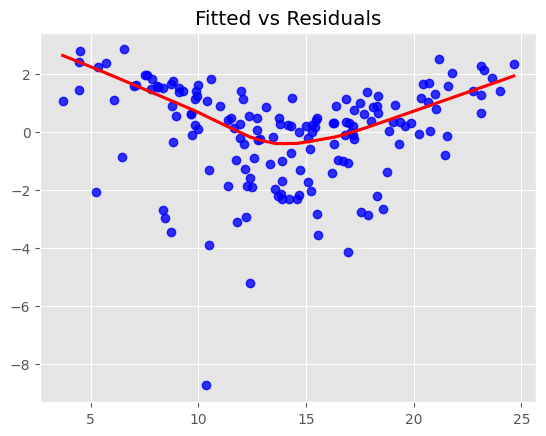

In [26]:
# Homocedasticidad: Igauldad de varianzas
sns.regplot(x=fitted_val,y = resid_val, color='blue', lowess=True, line_kws={'color':'red'})
plt.title('Fitted vs Residuals')

,const,TV,radio,newspaper
130,1.0,0.7,39.6,8.7
35,1.0,290.7,4.1,8.5
5,1.0,8.7,48.9,75.0
25,1.0,262.9,3.5,19.5
78,1.0,5.4,29.9,9.4
126,1.0,7.8,38.9,50.6


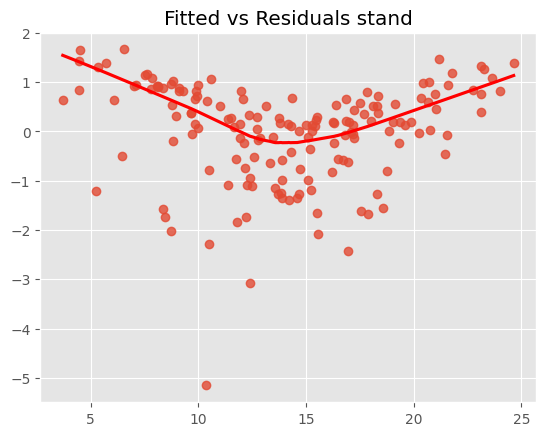

In [27]:
#OUTLIERS
# Es mejor usar los residuales estandarizados
resid_stand= modelo.get_influence().resid_studentized_internal
sns.regplot(x=fitted_val,y = resid_stand, lowess=True, line_kws={'color':'red'})
plt.title('Fitted vs Residuals stand')
 
# Umbral típico para outliers (|residuo| > 2)
outliers = abs(resid_stand) > 2
# Mostrar las observaciones con outliers
X_train[outliers]

In [28]:
#DISTANCIA DE COOK 
# Obtener la distancia de Cook
infl = modelo.get_influence()
distancia_cook = infl.cooks_distance[0]
 
# Umbral típico: valores > 4/n (donde n es el número de observaciones)
umbral = 4 / len(X_train)
outliers_cook = distancia_cook > umbral
 
# Mostrar las observaciones con alta influencia
X_train[outliers_cook]

,const,TV,radio,newspaper
130,1.0,0.7,39.6,8.7
35,1.0,290.7,4.1,8.5
5,1.0,8.7,48.9,75.0
165,1.0,234.5,3.4,84.8
91,1.0,28.6,1.5,33.0
25,1.0,262.9,3.5,19.5
75,1.0,16.9,43.7,89.4
131,1.0,265.2,2.9,43.0
2,1.0,17.2,45.9,69.3
78,1.0,5.4,29.9,9.4


*   ## Independencia de los errores
*   ## Homocedasticidad (Varianza constante de los errores)
*   ## Normalidad de los errores
*   ## No multicolinealidad



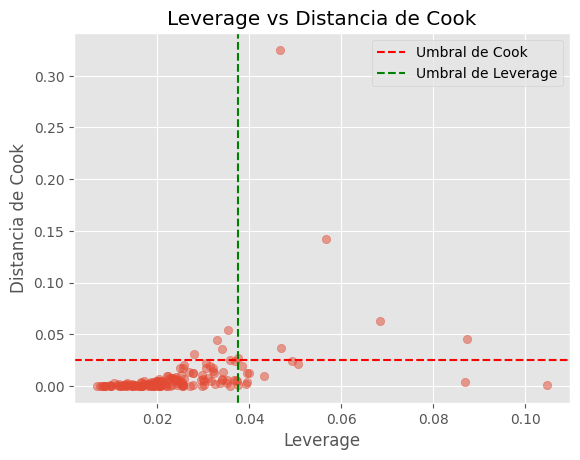

In [29]:
#LEVERGAE VS DISTANCIA COOK
# Leverage vs Distancia de Cook
 
# Obtener leverage
infl = modelo.get_influence()
leverage = infl.hat_matrix_diag
 
# Graficar leverage vs distancia de Cook
plt.scatter(leverage, distancia_cook, alpha=0.5)
plt.xlabel("Leverage")
plt.ylabel("Distancia de Cook")
plt.title("Leverage vs Distancia de Cook")
 
# Umbrales típicos
plt.axhline(y=umbral, color='r', linestyle='--', label="Umbral de Cook")
plt.axvline(x=2*modelo.df_model/len(X_train), color='g', linestyle='--', label="Umbral de Leverage")
plt.legend()
plt.show()
 
# Puntos con alta distancia de Cook  Son influyentes.
# Puntos con alto leverage  Son potenciales outliers.

In [30]:
#PUNTOS DE ALTA INFLUENCIA
# Obtener la influencia del modelo
influencia = modelo.get_influence()
 
# Calcular la distancia de Cook
distancia_cook = influencia.cooks_distance[0]
 
# Definir un umbral típico (4/n)
umbral_cook = 4 / len(X_train)
 
# Identificar observaciones con alta influencia
outliers_cook = np.where(distancia_cook > umbral_cook)[0]
 
# Mostrar las observaciones influyentes
X_train.iloc[outliers_cook]

,const,TV,radio,newspaper
130,1.0,0.7,39.6,8.7
35,1.0,290.7,4.1,8.5
5,1.0,8.7,48.9,75.0
165,1.0,234.5,3.4,84.8
91,1.0,28.6,1.5,33.0
25,1.0,262.9,3.5,19.5
75,1.0,16.9,43.7,89.4
131,1.0,265.2,2.9,43.0
2,1.0,17.2,45.9,69.3
78,1.0,5.4,29.9,9.4


valores limite de apalancamiento: 0.0625


0.0625

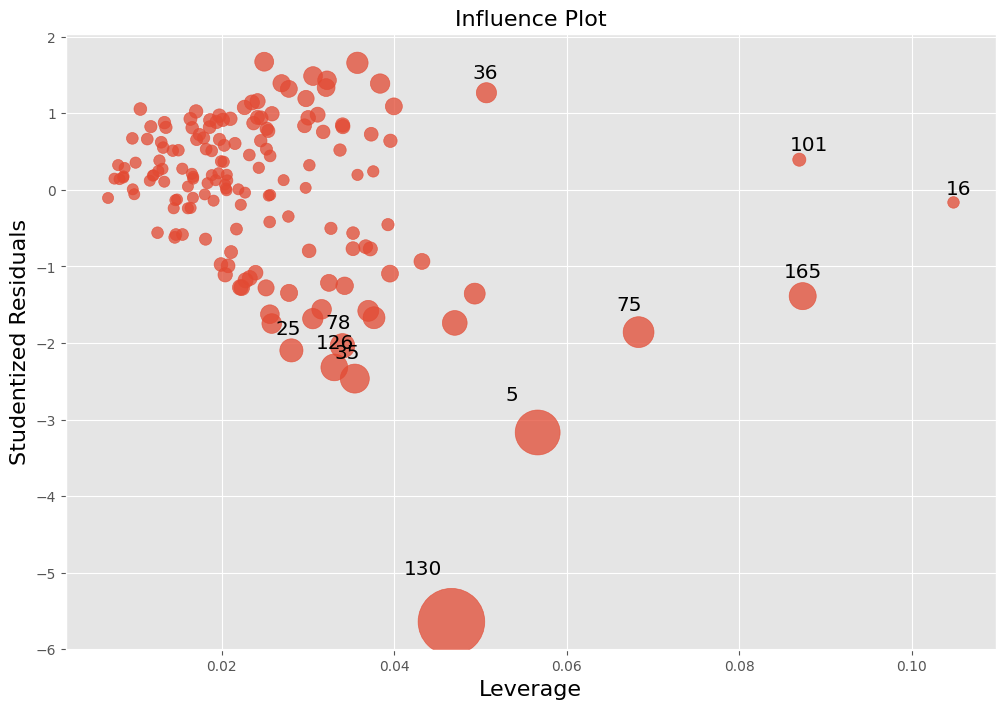

In [31]:
# Leverage points: Apalancamiento
 
# Influence points: cook distance (Gráfico de influencia)
fig, ax= plt.subplots(figsize=(12,8))
sm.graphics.influence_plot(modelo, alpha= 0.05, ax=ax,criterion="cooks")
 
# Para determinar los valores límites del apalancamiento, se utiliza la fórmula 2*p/n, donde
#p: el número de coeficientes
#n: el número de observaciones
print("valores limite de apalancamiento:", (2*(X_train.shape[1]+1))/X_train.shape[0])
 
2*((X_train.shape[1]+1)/X_train.shape[0])

In [33]:
X_train.loc[[130,165,16,101,5,75]]

,const,TV,radio,newspaper
130,1.0,0.7,39.6,8.7
165,1.0,234.5,3.4,84.8
16,1.0,67.8,36.6,114.0
101,1.0,296.4,36.3,100.9
5,1.0,8.7,48.9,75.0
75,1.0,16.9,43.7,89.4


In [34]:
y_train.loc[[130,165,16,101,5,75]]

130     1.6
165    11.9
16     12.5
101    23.8
5       7.2
75      8.7
Name: sales, dtype: float64

In [35]:
from numpy.linalg import cond

In [37]:
#COLINEALIDAD 
# Calcular número de condición
numero_condicion = cond(X_train)
print(f"Número de condición: {numero_condicion:.2f}")

Número de condición: 469.25


In [39]:
# Seleccionar solo las variables predictoras del modelo
X = X_train[['TV']]  # Reemplaza con todas las variables predictoras en tu modelo
 
# Agregar una constante para la regresión
X = sm.add_constant(X)
 
# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
 
# Mostrar resultados
print(vif_data)

  Variable       VIF
0    const  4.094792
1       TV  1.000000


## Conclusion del modelo


### Modelo 2


In [44]:
#Ajustamos un nuevo modelo que contenga a la variable newspaper
influence = modelo.get_influence()

Text(0, 0.5, 'Cooks Distance')

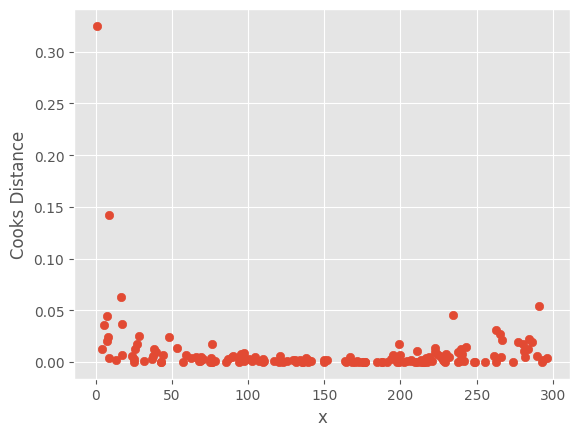

In [46]:
#Distancia de cook para tv
cooks = influence.cooks_distance

plt.scatter(X_train.TV, cooks[0])  
plt.xlabel('x')
plt.ylabel('Cooks Distance')
#plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

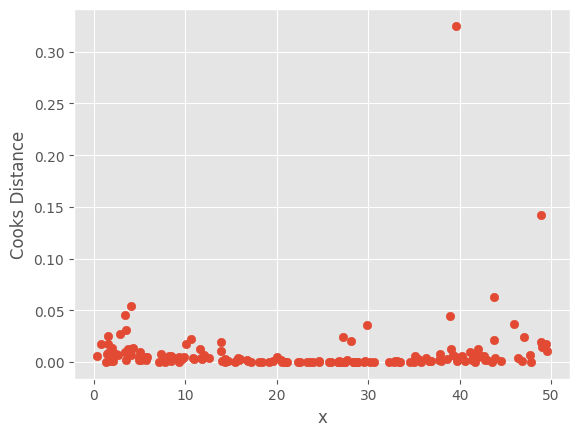

In [48]:
plt.scatter(X_train.radio, cooks[0])  
plt.xlabel('x')
plt.ylabel('Cooks Distance')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

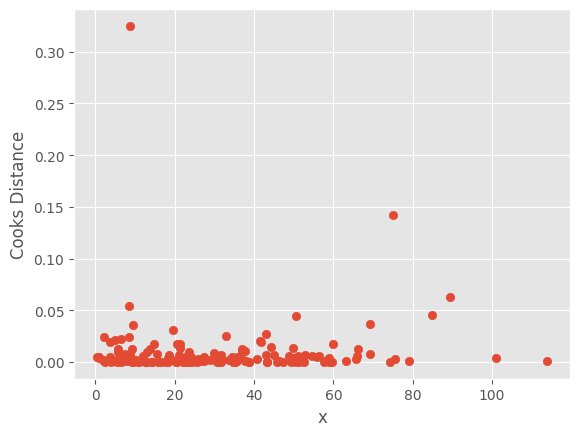

In [49]:
plt.scatter(X_train.newspaper, cooks[0])  
plt.xlabel('x')
plt.ylabel('Cooks Distance')
plt.show

In [51]:
#Elimnar las observaciones con leverage alto
k= cooks[0]>0.050

X_train[k]
y_train[k]

130     1.6
35     12.8
5       7.2
75      8.7
Name: sales, dtype: float64

In [52]:
X2_train = X_train.loc[ k!=1, : ]  ## X[k!=1]

y2_train = y_train[k!=1]

print(X2_train.shape)
print(y2_train.shape)

(156, 4)
(156,)


In [78]:
data2 = data.drop("newspaper", axis=1)
data2.head()

,TV,radio,sales
0,230.1,37.8,22.1
1,44.5,39.3,10.4
2,17.2,45.9,9.3
3,151.5,41.3,18.5
4,180.8,10.8,12.9


In [79]:
data2.isna().sum() #Contamos los datos N/A y los sumamos

TV       0
radio    0
sales    0
dtype: int64

In [96]:
X_orig1 = pd.DataFrame(data=data2, columns=['TV','radio'])
X_orig1.head()

data2 = data.drop("newspaper", axis=1)

y_orig1 = data2['sales']
y_orig1.head()

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_orig1, y_orig1, random_state=123,train_size = 0.8) #75% para entrenamiento, 25% para prueba
df = pd.concat([X_train1,y_train1], axis=1)
X_train1.shape
X_test1.shape
y_train1.shape
y_test1.shape

k1= cooks[0]>0.050

X_train1[k1]
y_train1[k1]

X2_train1 = X_train1.loc[ k1!=1, : ]  ## X[k!=1]

y2_train1 = y_train1[k1!=1]

X_train1=sm.add_constant(X_train1, prepend=True)
modelo1=sm.OLS(y_train1, X_train1)
modelo1=modelo1.fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     618.6
Date:                Sat, 01 Mar 2025   Prob (F-statistic):           3.53e-75
Time:                        13:12:36   Log-Likelihood:                -313.24
No. Observations:                 160   AIC:                             632.5
Df Residuals:                     157   BIC:                             641.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9142      0.348      8.383      0.0